In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

In [2]:
import kagglehub
import pandas as pd
import os

# Correct dataset handle
dataset_handle = "franckepeixoto/tabela-fipe"

# Download the dataset. This will download all files from the dataset to a local path.
# kagglehub.dataset_download returns the path to the root of the downloaded dataset.
print(f"Downloading dataset: {dataset_handle}...")
download_dir = kagglehub.dataset_download(dataset_handle)
print(f"Dataset downloaded to: {download_dir}")

# Assuming 'tabela-fipe-historico-precos.csv' is the file you want to load from the downloaded dataset
csv_file_name = "tabela-fipe-historico-precos.csv"
full_csv_path = os.path.join(download_dir, csv_file_name)

# Check if the file exists before loading
if os.path.exists(full_csv_path):
    df = pd.read_csv(full_csv_path)
    print(f"Loaded '{csv_file_name}' into a DataFrame named 'df_kagglehub'.")
    print("First 5 rows of the dataset loaded with kagglehub:")
else:
    print(f"Error: The file '{csv_file_name}' was not found in the downloaded dataset at {download_dir}")

# Note: The 'df' DataFrame from previous steps already contains this data.

100%|██████████| 5.62M/5.62M [00:00<00:00, 33.5MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/franckepeixoto/tabela-fipe/versions/1
Loaded 'tabela-fipe-historico-precos.csv' into a DataFrame named 'df_kagglehub'.
First 5 rows of the dataset loaded with kagglehub:


In [3]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [4]:
df.head()

,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor
0,038003-2,Acura,Integra GS 1.8,1992,11,2016,13041.0
1,038001-6,Acura,NSX 3.0,1995,3,2013,52339.0
2,038003-2,Acura,Integra GS 1.8,1992,3,2018,12423.0
3,038002-4,Acura,Legend 3.2/3.5,1998,5,2016,31067.0
4,038002-4,Acura,Legend 3.2/3.5,1998,2,2019,26381.0


In [32]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"DataFrame shape after duplicate removal: {df.shape}")

Number of duplicate rows before removal: 0
Number of duplicate rows after removal: 0
DataFrame shape after duplicate removal: (363092, 13)


## Analise

In [5]:
df.describe()


,anoModelo,mesReferencia,anoReferencia,valor
count,466020.000000,466020.000000,466020.000000,4.660200e+05
mean,2008.968325,6.453541,2015.181181,1.157456e+05
std,9.999445,3.417056,5.677257,3.250737e+05
min,1985.000000,1.000000,2001.000000,1.871000e+03
25%,2000.000000,4.000000,2011.000000,1.938800e+04
50%,2009.000000,6.000000,2017.000000,3.941650e+04
75%,2020.000000,9.000000,2020.000000,8.479450e+04
max,2023.000000,12.000000,2022.000000,8.407082e+06


In [14]:
df.isnull().sum()

,0
codigoFipe,0
marca,0
modelo,0
anoModelo,0
mesReferencia,0
anoReferencia,0
valor,0


In [17]:
tabela_marcas_completa = df['marca'].value_counts().sort_values(ascending=False).reset_index()
tabela_marcas_completa.columns = ['Marca', 'Quantidade']
tabela_marcas_completa

,Marca,Quantidade
0,Renault,44464
1,Peugeot,41828
2,Audi,33837
3,VW - VolksWagen,29838
4,Ford,26128
...,...,...
79,Baby,156
80,Cross Lander,131
81,Mahindra,79
82,RAM,19


### Separar os dados para um periodo de 10 anos e fazer uma avaliação temporal da variação de preço

In [6]:
df = df[df["anoReferencia"] >= 2011].sort_values(by = ["anoReferencia", "mesReferencia", "marca", "anoModelo"])
df.groupby("anoReferencia")["valor"].mean()

,valor
anoReferencia,
2011,84724.095983
2012,88457.516315
2013,98357.445548
2014,102687.342650
2015,113390.574963
2016,108420.125750
2017,106109.330403
2018,115389.741672
2019,122645.094928


###  variação anual de valores anuais dos veiculos

In [7]:
df['variacao'] = df.groupby(['marca', 'modelo'])['valor'].pct_change()
df['valorizou'] = df['variacao'].gt(0)

In [9]:
df['media_geral_ano'] = df.groupby('anoReferencia')['variacao'].transform('mean')

In [10]:
df['desvio_media'] = df['variacao'] - df['media_geral_ano']

In [11]:
df['zscore'] = df.groupby('anoReferencia')['variacao'].transform(
    lambda x: (x - x.mean()) / x.std()
)

In [12]:
df['destoa'] = df['zscore'].abs() > 2

In [13]:
df["destoa"].value_counts()

,count
destoa,
False,356978
True,6114


In [14]:
destaques = df[df['destoa']].sort_values(['anoReferencia', 'zscore'], ascending=[True, False])
destaques

,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor,variacao,valorizou,media_geral_ano,desvio_media,zscore,destoa
144123,015006-1,Hyundai,Elantra GLS 1.8 16V,2022,11,2011,80624.0,5.722028,True,-0.001450,5.723477,96.432620,True
388574,028017-8,Suzuki,Vitara JLX 2.0 V6 4x4,2022,11,2011,84922.0,2.416972,True,-0.001450,2.418422,40.747033,True
315947,035009-5,Porsche,911 GT3/ GT2 Street,2022,11,2011,1126250.0,1.598129,True,-0.001450,1.599579,26.950675,True
53695,010029-3,Chrysler,300 C 3.5 V6 249cv,2022,11,2011,183800.0,0.749493,True,-0.001450,0.750943,12.652341,True
192635,063001-2,LOBINI,H1 1.8 20V Turbo 180cv 2p,2022,11,2011,179000.0,0.669309,True,-0.001450,0.670759,11.301349,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
92128,001235-1,Fiat,Doblo Cargo 1.8 mpi Fire Flex 8V/16V 4p,2021,7,2022,95109.0,-0.214040,False,0.006591,-0.220631,-8.773573,True
191939,077007-8,LIFAN,X60 VIP 1.8 16V 128cv 5p Aut.,2019,7,2022,64677.0,-0.231235,False,0.006591,-0.237825,-9.457326,True
371195,055039-6,SSANGYONG,TIVOLI 1.6 16V 128cv Aut.,2018,6,2022,78300.0,-0.286521,False,0.006591,-0.293112,-11.655850,True
92559,001424-9,Fiat,UNO ATTRACTIVE 1.0 Fire Flex 8V 5p,2021,7,2022,51962.0,-0.298219,False,0.006591,-0.304809,-12.121001,True


In [19]:
OUTPUT_DIR = Path("fipe_graficos")
OUTPUT_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "axes.titlesize":    13,
    "axes.titleweight":  "bold",
})

COR_POSITIVO = "#1D9E75"
COR_NEGATIVO = "#D85A30"
COR_MERCADO  = "#185FA5"

def salvar(fig, nome):
    caminho = OUTPUT_DIR / nome
    fig.savefig(caminho, dpi=150, bbox_inches="tight")
    print(f"salvo em: {caminho}")

In [20]:
media_mercado = df.groupby("anoReferencia")["variacao"].mean()

ranking_marcas = (
    df.dropna(subset=["variacao"])
    .groupby("marca")["variacao"]
    .mean()
    .sort_values(ascending=False)
)
top5_marcas = ranking_marcas.head(5)
bot5_marcas = ranking_marcas.tail(5).sort_values(ascending=True)

ranking_modelos = (
    df.dropna(subset=["variacao"])
    .groupby(["marca", "modelo"])
    .agg(variacao_media=("variacao", "mean"))
    .reset_index()
    .assign(label=lambda x: x["marca"] + " — " + x["modelo"])
    .sort_values("variacao_media", ascending=False)
)
top10_modelos = ranking_modelos.head(10).sort_values("variacao_media")
bot10_modelos = ranking_modelos.tail(10).sort_values("variacao_media", ascending=False)

print(f"anos disponíveis : {sorted(df['anoReferencia'].unique())}")
print(f"total de marcas  : {df['marca'].nunique()}")
print(f"total de modelos : {df['modelo'].nunique()}")


anos disponíveis : [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
total de marcas  : 81
total de modelos : 5250


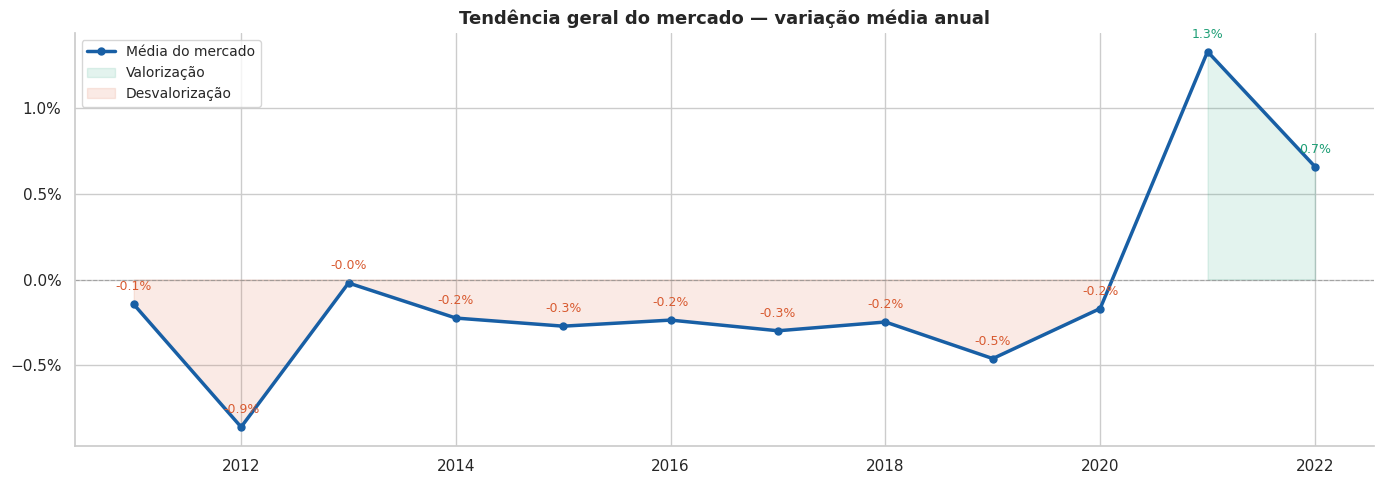

salvo em: fipe_graficos/01_tendencia_geral.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    media_mercado.index,
    media_mercado.values * 100,
    color=COR_MERCADO,
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Média do mercado",
)
ax.axhline(0, color="#888", linewidth=0.8, linestyle="--", alpha=0.6)
ax.fill_between(
    media_mercado.index, media_mercado.values * 100, 0,
    where=media_mercado.values >= 0,
    alpha=0.12, color=COR_POSITIVO, label="Valorização",
)
ax.fill_between(
    media_mercado.index, media_mercado.values * 100, 0,
    where=media_mercado.values < 0,
    alpha=0.12, color=COR_NEGATIVO, label="Desvalorização",
)

for ano, val in zip(media_mercado.index, media_mercado.values):
    ax.annotate(
        f"{val*100:.1f}%",
        xy=(ano, val * 100),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=COR_POSITIVO if val >= 0 else COR_NEGATIVO,
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.set_title("Tendência geral do mercado — variação média anual")
ax.set_xlabel("")
ax.legend(fontsize=10)
fig.tight_layout()

plt.show()
salvar(fig, "01_tendencia_geral.png")

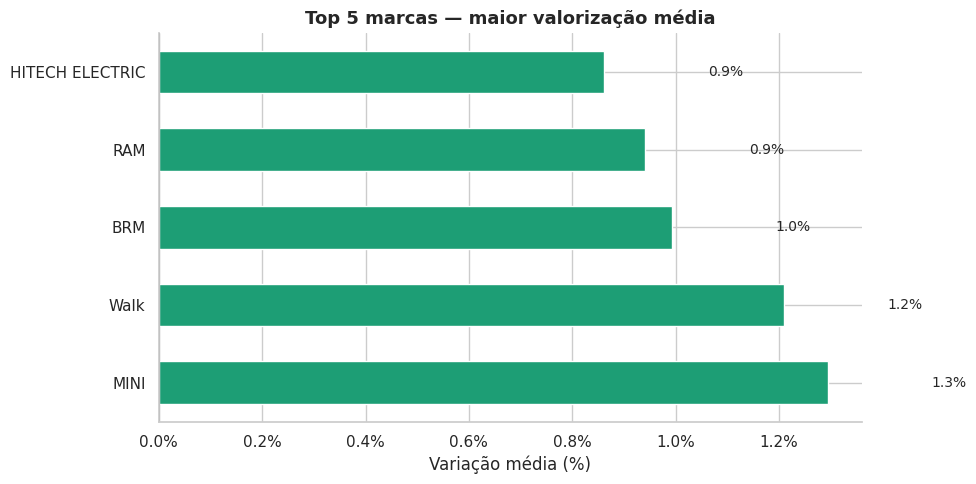

salvo em: fipe_graficos/02_top5_marcas.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

cores = [COR_POSITIVO if v >= 0 else COR_NEGATIVO for v in top5_marcas.values]
bars  = ax.barh(top5_marcas.index, top5_marcas.values * 100, color=cores, height=0.55)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_title("Top 5 marcas — maior valorização média")
ax.set_xlabel("Variação média (%)")

for bar, val in zip(bars, top5_marcas.values):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.1f}%",
        va="center", ha="left", fontsize=10,
    )

fig.tight_layout()
plt.show()
salvar(fig, "02_top5_marcas.png")

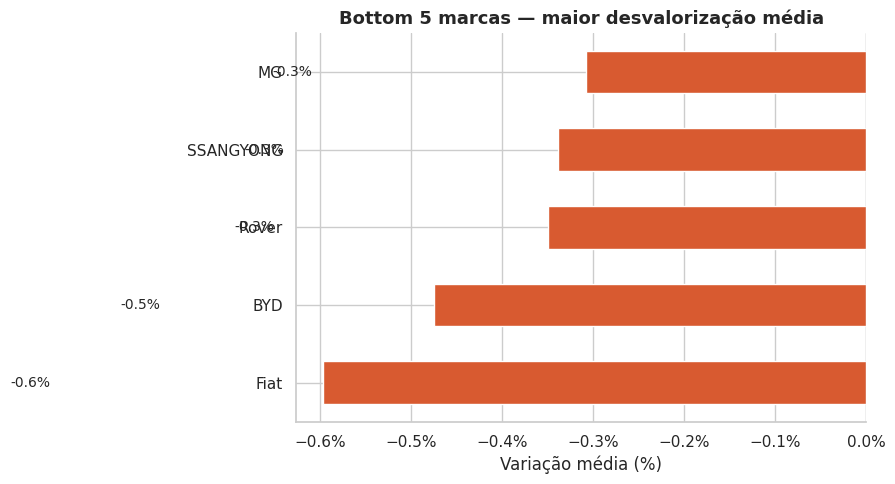

salvo em: fipe_graficos/03_bot5_marcas.png


In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

cores = [COR_POSITIVO if v >= 0 else COR_NEGATIVO for v in bot5_marcas.values]
bars  = ax.barh(bot5_marcas.index, bot5_marcas.values * 100, color=cores, height=0.55)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_title("Bottom 5 marcas — maior desvalorização média")
ax.set_xlabel("Variação média (%)")

for bar, val in zip(bars, bot5_marcas.values):
    offset = -0.3 if val < 0 else 0.2
    ha     = "right" if val < 0 else "left"
    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.1f}%",
        va="center", ha=ha, fontsize=10,
    )

fig.tight_layout()
plt.show()
salvar(fig, "03_bot5_marcas.png")

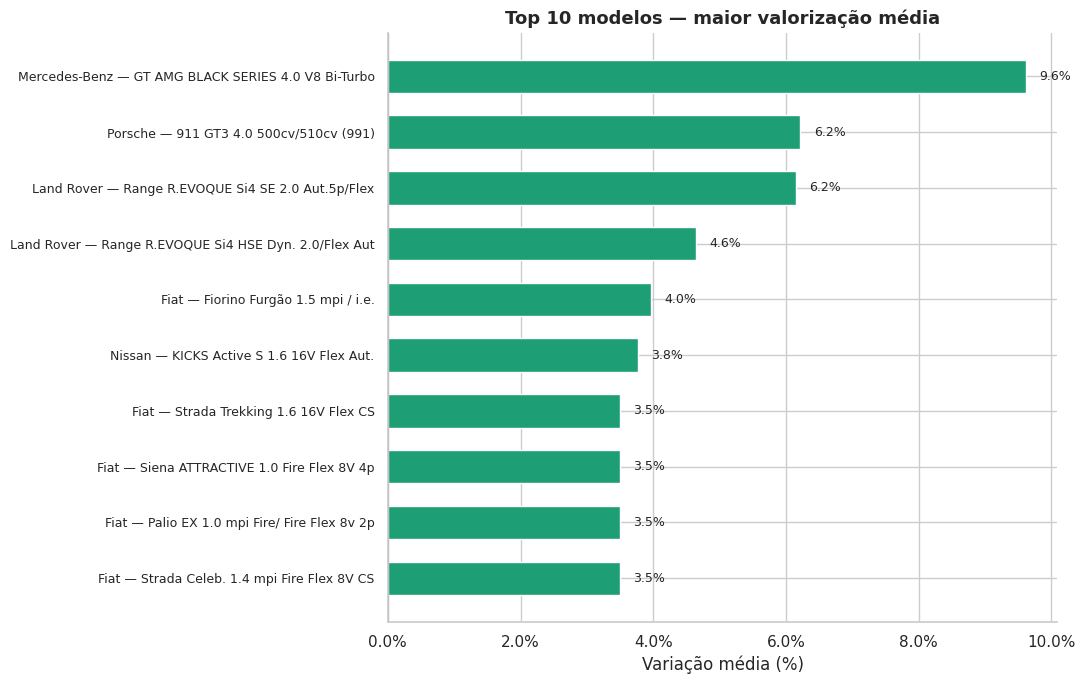

salvo em: fipe_graficos/04_top10_modelos.png


In [24]:
fig, ax = plt.subplots(figsize=(11, 7))

cores = [COR_POSITIVO if v >= 0 else COR_NEGATIVO for v in top10_modelos["variacao_media"]]
bars  = ax.barh(top10_modelos["label"], top10_modelos["variacao_media"] * 100,
                color=cores, height=0.6)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_title("Top 10 modelos — maior valorização média")
ax.set_xlabel("Variação média (%)")
ax.tick_params(axis="y", labelsize=9)

for bar, val in zip(bars, top10_modelos["variacao_media"]):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.1f}%",
        va="center", ha="left", fontsize=9,
    )

fig.tight_layout()
plt.show()
salvar(fig, "04_top10_modelos.png")

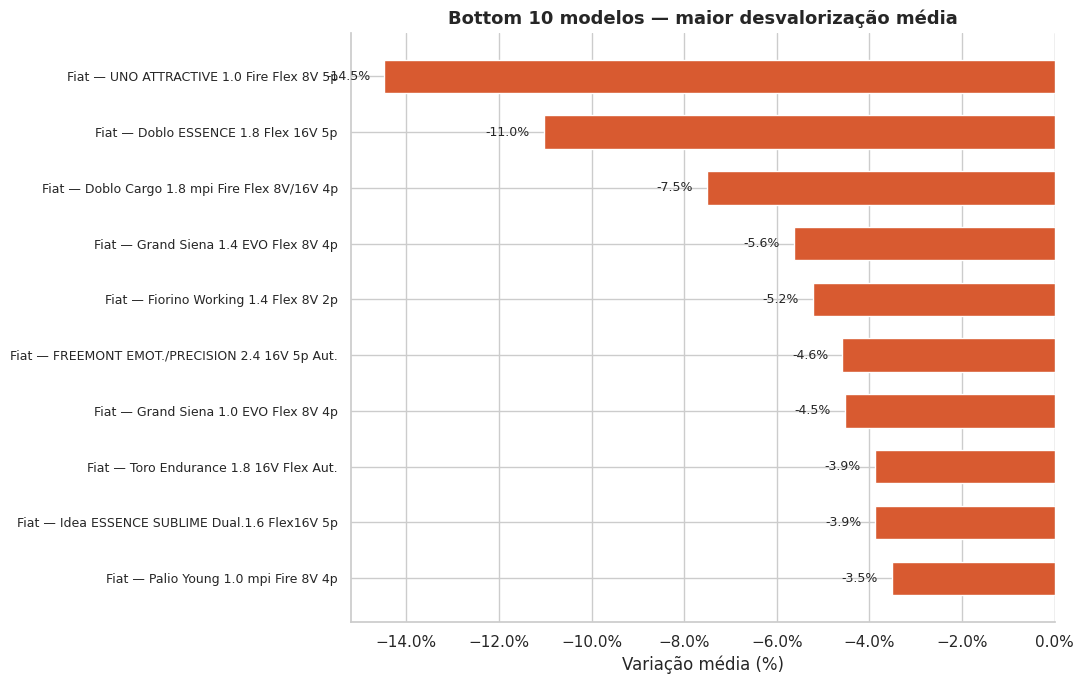

salvo em: fipe_graficos/05_bot10_modelos.png


In [25]:
fig, ax = plt.subplots(figsize=(11, 7))

cores = [COR_POSITIVO if v >= 0 else COR_NEGATIVO for v in bot10_modelos["variacao_media"]]
bars  = ax.barh(bot10_modelos["label"], bot10_modelos["variacao_media"] * 100,
                color=cores, height=0.6)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax.axvline(0, color="#888", linewidth=0.8)
ax.set_title("Bottom 10 modelos — maior desvalorização média")
ax.set_xlabel("Variação média (%)")
ax.tick_params(axis="y", labelsize=9)

for bar, val in zip(bars, bot10_modelos["variacao_media"]):
    offset = -0.3 if val < 0 else 0.2
    ha     = "right" if val < 0 else "left"
    ax.text(
        bar.get_width() + offset,
        bar.get_y() + bar.get_height() / 2,
        f"{val*100:.1f}%",
        va="center", ha=ha, fontsize=9,
    )

fig.tight_layout()
plt.show()
salvar(fig, "05_bot10_modelos.png")

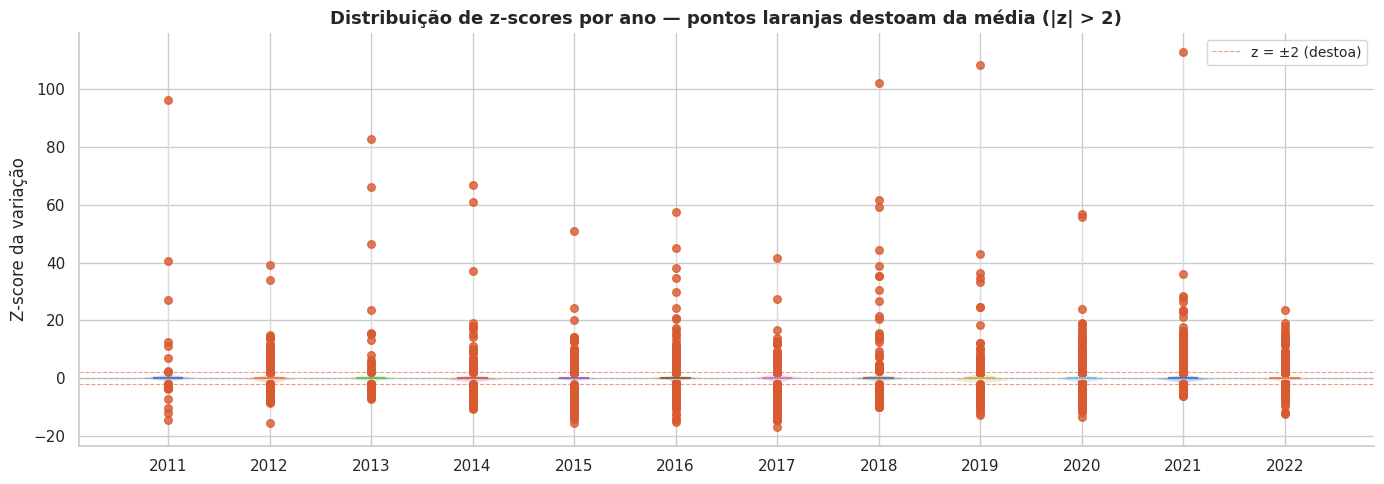

salvo em: fipe_graficos/06_zscore_distribuicao.png


In [26]:
anos = sorted(df["anoReferencia"].dropna().unique())
fig, ax = plt.subplots(figsize=(14, 5))

for i, ano in enumerate(anos):
    dados = df[df["anoReferencia"] == ano]["zscore"].dropna()
    ax.violinplot(dados, positions=[i], widths=0.6,
                  showmedians=True, showextrema=False)

    outliers = df[(df["anoReferencia"] == ano) & (df["zscore"].abs() > 2)]
    ax.scatter(
        [i] * len(outliers),
        outliers["zscore"],
        color=COR_NEGATIVO, s=30, zorder=5, alpha=0.8,
    )

ax.axhline( 2, color=COR_NEGATIVO, linewidth=0.8, linestyle="--", alpha=0.6, label="z = ±2 (destoa)")
ax.axhline(-2, color=COR_NEGATIVO, linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline( 0, color="#888",       linewidth=0.8, linestyle="--", alpha=0.4)

ax.set_xticks(range(len(anos)))
ax.set_xticklabels(anos)
ax.set_ylabel("Z-score da variação")
ax.set_title("Distribuição de z-scores por ano — pontos laranjas destoam da média (|z| > 2)")
ax.legend(fontsize=10)

fig.tight_layout()
plt.show()
salvar(fig, "06_zscore_distribuicao.png")


In [27]:
destaques = (
    df[df["zscore"].abs() > 2]
    .dropna(subset=["zscore"])
    [["anoReferencia", "marca", "modelo", "valor", "variacao", "zscore"]]
    .assign(
        variacao=lambda x: (x["variacao"] * 100).round(2),
        zscore=lambda x: x["zscore"].round(2),
    )
    .rename(columns={"variacao": "variacao (%)"})
    .sort_values(["anoReferencia", "zscore"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"\nTotal de registros que destoam: {len(destaques)}\n")
destaques


Total de registros que destoam: 6114



,anoReferencia,marca,modelo,valor,variacao (%),zscore
0,2011,Hyundai,Elantra GLS 1.8 16V,80624.0,572.20,96.43
1,2011,Suzuki,Vitara JLX 2.0 V6 4x4,84922.0,241.70,40.75
2,2011,Porsche,911 GT3/ GT2 Street,1126250.0,159.81,26.95
3,2011,Chrysler,300 C 3.5 V6 249cv,183800.0,74.95,12.65
4,2011,LOBINI,H1 1.8 20V Turbo 180cv 2p,179000.0,66.93,11.30
...,...,...,...,...,...,...
6109,2022,Fiat,Doblo Cargo 1.8 mpi Fire Flex 8V/16V 4p,95109.0,-21.40,-8.77
6110,2022,LIFAN,X60 VIP 1.8 16V 128cv 5p Aut.,64677.0,-23.12,-9.46
6111,2022,SSANGYONG,TIVOLI 1.6 16V 128cv Aut.,78300.0,-28.65,-11.66
6112,2022,Fiat,UNO ATTRACTIVE 1.0 Fire Flex 8V 5p,51962.0,-29.82,-12.12


**Reasoning**:
To analyze the correlations, I will first identify the numerical columns, then calculate the correlation matrix and visualize the correlations of these numerical columns with the 'valor' column.



In [31]:
df.head()

,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor,variacao,valorizou,media_geral_ano,desvio_media,zscore,destoa
98,038003-2,Acura,Integra GS 1.8,1992,1,2011,15583.0,NaN,False,-0.00145,NaN,NaN,False
422,038001-6,Acura,NSX 3.0,1995,1,2011,62391.0,NaN,False,-0.00145,NaN,NaN,False
251,038002-4,Acura,Legend 3.2/3.5,1998,1,2011,34487.0,NaN,False,-0.00145,NaN,NaN,False
782,006013-5,Alfa Romeo,2300 TI/TI-4,1986,1,2011,7888.0,NaN,False,-0.00145,NaN,NaN,False
2021,006005-4,Alfa Romeo,164 3.0 V6,1996,1,2011,13455.0,NaN,False,-0.00145,NaN,NaN,False


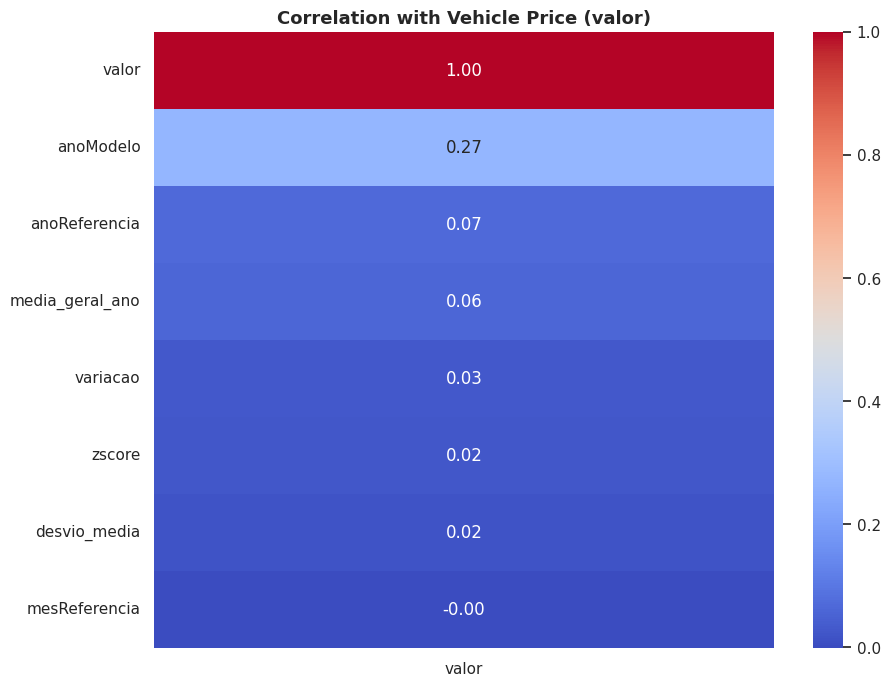

In [30]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix[['valor']].sort_values(by='valor', ascending=False), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation with Vehicle Price (valor)')
plt.show()


**Reasoning**:
To calculate the vehicle's age, I will subtract the 'anoModelo' from 'anoReferencia' and store the result in a new column named 'vehicle_age'.



In [33]:
df['vehicle_age'] = df['anoReferencia'] - df['anoModelo']

**Reasoning**:
To determine the percentage price variation, I will first calculate the average price for each model per reference year, sort the data, and then calculate the percentage change of the 'valor' column within each 'modelo' group.



In [34]:
df.head()

,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor,variacao,valorizou,media_geral_ano,desvio_media,zscore,destoa,vehicle_age
98,038003-2,Acura,Integra GS 1.8,1992,1,2011,15583.0,NaN,False,-0.00145,NaN,NaN,False,19
422,038001-6,Acura,NSX 3.0,1995,1,2011,62391.0,NaN,False,-0.00145,NaN,NaN,False,16
251,038002-4,Acura,Legend 3.2/3.5,1998,1,2011,34487.0,NaN,False,-0.00145,NaN,NaN,False,13
782,006013-5,Alfa Romeo,2300 TI/TI-4,1986,1,2011,7888.0,NaN,False,-0.00145,NaN,NaN,False,25
2021,006005-4,Alfa Romeo,164 3.0 V6,1996,1,2011,13455.0,NaN,False,-0.00145,NaN,NaN,False,15


In [35]:
avg_price_per_model_year = df.groupby(['modelo', 'anoReferencia'])['valor'].mean().reset_index()

avg_price_per_model_year = avg_price_per_model_year.sort_values(by=['modelo', 'anoReferencia'])

avg_price_per_model_year['price_variation_pct'] = avg_price_per_model_year.groupby('modelo')['valor'].pct_change() * 100

df = pd.merge(df, avg_price_per_model_year[['modelo', 'anoReferencia', 'price_variation_pct']],
                         on=['modelo', 'anoReferencia'], how='left')

print(df[['modelo', 'anoReferencia', 'valor', 'price_variation_pct']].head())

           modelo  anoReferencia    valor  price_variation_pct
0  Integra GS 1.8           2011  15583.0                  NaN
1         NSX 3.0           2011  62391.0                  NaN
2  Legend 3.2/3.5           2011  34487.0                  NaN
3    2300 TI/TI-4           2011   7888.0                  NaN
4      164 3.0 V6           2011  13455.0                  NaN


**Reasoning**:
To calculate the price positioning index, I will first calculate the overall market average price per `anoReferencia`. Then, I will calculate the average price for each `marca` per `anoReferencia`. Finally, I will compute the `price_positioning_index` by dividing the brand average price by the market average price and multiplying by 100, and merge this back into the main DataFrame.



In [36]:
market_avg_price_year = df.groupby('anoReferencia')['valor'].mean().reset_index().rename(columns={'valor': 'market_avg_price'})

brand_avg_price_year = df.groupby(['marca', 'anoReferencia'])['valor'].mean().reset_index().rename(columns={'valor': 'brand_avg_price'})

price_index_data = pd.merge(brand_avg_price_year, market_avg_price_year, on='anoReferencia', how='left')
price_index_data['price_positioning_index'] = (price_index_data['brand_avg_price'] / price_index_data['market_avg_price']) * 100

df = pd.merge(df, price_index_data[['marca', 'anoReferencia', 'price_positioning_index']],
                         on=['marca', 'anoReferencia'], how='left')

print(df[['marca', 'anoReferencia', 'valor', 'price_positioning_index']].head())

        marca  anoReferencia    valor  price_positioning_index
0       Acura           2011  15583.0                44.736519
1       Acura           2011  62391.0                44.736519
2       Acura           2011  34487.0                44.736519
3  Alfa Romeo           2011   7888.0                35.482410
4  Alfa Romeo           2011  13455.0                35.482410


## Feature Engineering

In [46]:
df_sample = df.sample(n=100000, random_state=42)
print(f"DataFrame sampled with {len(df_sample)} rows.")
df_sample.head(3)

DataFrame sampled with 100000 rows.


,codigoFipe,marca,modelo,anoModelo,mesReferencia,anoReferencia,valor,variacao,valorizou,media_geral_ano,desvio_media,zscore,destoa,vehicle_age,price_variation_pct,price_positioning_index
240924,005023-7,VW - VolksWagen,Kombi Furgão,2006,2,2020,16529.0,0.005964,True,-0.001694,0.007658,0.455818,False,14,1.592777,28.210851
278778,027042-3,Subaru,Impreza SW GX 2.0 16v 4x4 Aut.,2002,12,2020,25003.0,-0.001916,False,-0.001694,-0.000223,-0.013248,False,18,-2.305239,40.254448
197147,005091-1,VW - VolksWagen,Passat Variant Turbo 1.8,2004,2,2019,22746.0,-0.001712,False,-0.004617,0.002905,0.148936,False,15,-4.328694,30.469578


In [47]:
df_encoded = pd.get_dummies(df_sample, columns=['marca'], drop_first=True)
print("One-hot encoded 'marca' column.")
print(df_encoded.head())


One-hot encoded 'marca' column.
       codigoFipe                             modelo  anoModelo  \
240924   005023-7                       Kombi Furgão       2006   
278778   027042-3     Impreza SW GX 2.0 16v 4x4 Aut.       2002   
197147   005091-1           Passat Variant Turbo 1.8       2004   
223301   030006-3           Leganza CDX 2.0 16V Mec.       1999   
186109   025208-5  LOGAN Dynamique Hi-Flex 1.6 8V 4p       2017   

        mesReferencia  anoReferencia    valor  variacao  valorizou  \
240924              2           2020  16529.0  0.005964       True   
278778             12           2020  25003.0 -0.001916      False   
197147              2           2019  22746.0 -0.001712      False   
223301             10           2019   8595.0 -0.002785      False   
186109             11           2018  46255.0  0.013564       True   

        media_geral_ano  desvio_media  ...  marca_Seat  marca_Subaru  \
240924        -0.001694      0.007658  ...       False         False   


**Reasoning**:
Normalize selected numerical features using StandardScaler to ensure they have a mean of 0 and a standard deviation of 1, which is important for many machine learning algorithms.



In [48]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to normalize (excluding the target 'valor' and 'Unnamed: 0' index)
columns_to_normalize = ['anoModelo', 'mesReferencia', 'anoReferencia', 'vehicle_age', 'price_variation_pct', 'price_positioning_index']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified columns
df_encoded[columns_to_normalize] = scaler.fit_transform(df_encoded[columns_to_normalize])

print("Numerical features normalized:")
print(df_encoded[columns_to_normalize].head())


Numerical features normalized:
        anoModelo  mesReferencia  anoReferencia  vehicle_age  \
240924  -0.369149      -1.298207       0.722319     0.598405   
278778  -0.791084       1.640103       0.722319     1.012514   
197147  -0.580117      -1.298207       0.405593     0.701932   
223301  -1.107535       1.052441       0.405593     1.219569   
186109   0.791170       1.346272       0.088867    -0.747449   

        price_variation_pct  price_positioning_index  
240924             0.200107                -0.327428  
278778            -0.190061                -0.272030  
197147            -0.392596                -0.317038  
223301            -0.482922                -0.430418  
186109            -0.746168                -0.330633  


**Reasoning**:
To treat price outliers, I will use the IQR method. First, calculate the IQR for the 'valor' column. Then, identify outliers as values outside 1.5 times the IQR from the first and third quartiles. Finally, replace these outliers with the upper or lower bounds.



In [49]:
Q1 = df_encoded['valor'].quantile(0.25)
Q3 = df_encoded['valor'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap outliers
df_encoded['valor'] = np.where(df_encoded['valor'] < lower_bound, lower_bound, df_encoded['valor'])
df_encoded['valor'] = np.where(df_encoded['valor'] > upper_bound, upper_bound, df_encoded['valor'])

print(f"Outliers in 'valor' column treated. Values below {lower_bound:.2f} are set to {lower_bound:.2f}, and values above {upper_bound:.2f} are set to {upper_bound:.2f}.")
print(df_encoded[['valor']].describe())

Outliers in 'valor' column treated. Values below -81107.38 are set to -81107.38, and values above 185157.62 are set to 185157.62.
               valor
count  100000.000000
mean    63308.447231
std     59074.104163
min      1876.000000
25%     18742.000000
50%     39451.500000
75%     85308.250000
max    185157.625000


In [50]:
from sklearn.model_selection import train_test_split

# Identify features (X) and target (y)
X = df_encoded.drop(['valor', 'codigoFipe', 'modelo'], axis=1)
y = df_encoded['valor']

# Impute missing values in X with the mean of each column
X = X.fillna(X.mean())

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets:
X_train shape: (80000, 90)
X_test shape: (20000, 90)
y_train shape: (80000,)
y_test shape: (20000,)


## Etapa 2

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

# Initialize the models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42)
}

print("Initialized regression models:")
for name, model in models.items():
    print(f"- {name}: {model}")

Initialized regression models:
- Linear Regression: LinearRegression()
- Decision Tree Regressor: DecisionTreeRegressor(random_state=42)
- Random Forest Regressor: RandomForestRegressor(random_state=42)
- Gradient Boosting Regressor: GradientBoostingRegressor(random_state=42)
- XGBoost Regressor: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
        

In [57]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

print("Starting K-Fold Cross-Validation...")

for name, model in models.items():
    model_rmse = []
    model_r2 = []
    model_mae = []

    print(f"\nEvaluating {name} with K-Fold Cross-Validation...")
    for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
        X_train_cv, X_val_cv = X.iloc[train_index], X.iloc[val_index]
        y_train_cv, y_val_cv = y.iloc[train_index], y.iloc[val_index]

        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_val_cv)

        rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred_cv))
        r2 = r2_score(y_val_cv, y_pred_cv)
        mae = mean_absolute_error(y_val_cv, y_pred_cv)

        model_rmse.append(rmse)
        model_r2.append(r2)
        model_mae.append(mae)
        print(f"  Fold {fold+1} - RMSE: {rmse:.2f}, R2: {r2:.4f}, MAE: {mae:.2f}")

    cv_results.append({
        'Model': name,
        'Mean RMSE': np.mean(model_rmse),
        'Std RMSE': np.std(model_rmse),
        'Mean R2 Score': np.mean(model_r2),
        'Std R2 Score': np.std(model_r2),
        'Mean MAE': np.mean(model_mae),
        'Std MAE': np.std(model_mae)
    })

cv_metrics_df = pd.DataFrame(cv_results)
print("\nK-Fold Cross-Validation Results (Mean and Standard Deviation):")
print(cv_metrics_df.sort_values(by='Mean RMSE'))

Starting K-Fold Cross-Validation...

Evaluating Linear Regression with K-Fold Cross-Validation...
  Fold 1 - RMSE: 27606.37, R2: 0.7793, MAE: 20763.31
  Fold 2 - RMSE: 27732.18, R2: 0.7783, MAE: 20842.53
  Fold 3 - RMSE: 27745.48, R2: 0.7809, MAE: 20660.98
  Fold 4 - RMSE: 27858.12, R2: 0.7797, MAE: 20958.12
  Fold 5 - RMSE: 27661.04, R2: 0.7807, MAE: 20752.08

Evaluating Decision Tree Regressor with K-Fold Cross-Validation...
  Fold 1 - RMSE: 19129.44, R2: 0.8940, MAE: 7678.93
  Fold 2 - RMSE: 19475.66, R2: 0.8907, MAE: 7848.92
  Fold 3 - RMSE: 18556.78, R2: 0.9020, MAE: 7440.84
  Fold 4 - RMSE: 19108.39, R2: 0.8964, MAE: 7681.84
  Fold 5 - RMSE: 18944.46, R2: 0.8971, MAE: 7666.10

Evaluating Random Forest Regressor with K-Fold Cross-Validation...
  Fold 1 - RMSE: 14993.12, R2: 0.9349, MAE: 7822.59
  Fold 2 - RMSE: 15258.82, R2: 0.9329, MAE: 7927.05
  Fold 3 - RMSE: 15008.70, R2: 0.9359, MAE: 7758.27
  Fold 4 - RMSE: 15130.07, R2: 0.9350, MAE: 7848.69
  Fold 5 - RMSE: 14880.75, R2: 0.


## Análise da Importância das Features e Serialização do Melhor Modelo

Com base nos resultados da validação cruzada K-Fold, o **Random Forest Regressor** demonstrou ser o modelo mais robusto e com melhor desempenho. Agora, vamos analisar a importância de suas features para entender quais variáveis mais influenciam a precificação dos veículos.

Depois da análise, o modelo será serializado para uso futuro.
```

O melhor modelo identificado é: Random Forest Regressor

Top 15 Features Mais Importantes:
                    Feature  Importance
11  price_positioning_index    0.504998
0                 anoModelo    0.338500
10      price_variation_pct    0.048358
3                  variacao    0.013953
9               vehicle_age    0.013200
7                    zscore    0.011500
6              desvio_media    0.010901
2             anoReferencia    0.009528
1             mesReferencia    0.008763
86              marca_Volvo    0.005442
5           media_geral_ano    0.004363
81             marca_Subaru    0.003987
24           marca_Chrysler    0.002855
35               marca_Ford    0.001517
28              marca_Dodge    0.001393


/tmp/ipykernel_28990/1295968318.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=features_df.head(15), ax=ax, palette='viridis')


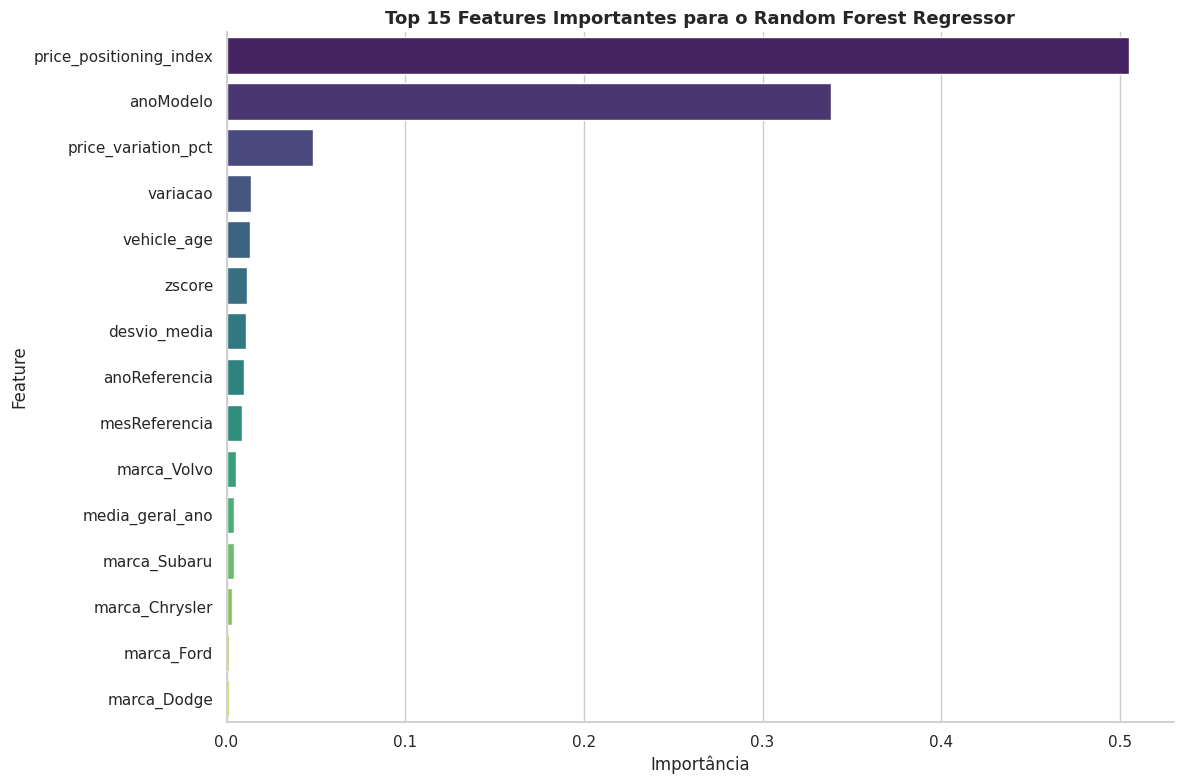

salvo em: fipe_graficos/07_feature_importance.png


In [58]:
# Identificar o melhor modelo com base no Mean RMSE da validação cruzada
best_model_name = cv_metrics_df.sort_values(by='Mean RMSE').iloc[0]['Model']
best_model = models[best_model_name]

print(f"O melhor modelo identificado é: {best_model_name}")

# Obter a importância das features
if hasattr(best_model, 'feature_importances_'):
    feature_importances = best_model.feature_importances_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})
    features_df = features_df.sort_values(by='Importance', ascending=False)

    print("\nTop 15 Features Mais Importantes:")
    print(features_df.head(15))

    # Visualizar a importância das features
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_df.head(15), ax=ax, palette='viridis')
    ax.set_title(f'Top 15 Features Importantes para o {best_model_name}')
    ax.set_xlabel('Importância')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
    salvar(fig, '07_feature_importance.png')
elif hasattr(best_model, 'coef_'):
    # Para modelos lineares, os coeficientes podem indicar importância
    coefficients = best_model.coef_
    features_df = pd.DataFrame({'Feature': X.columns, 'Importance': np.abs(coefficients)})
    features_df = features_df.sort_values(by='Importance', ascending=False)

    print("\nTop 15 Features Mais Importantes (baseado em coeficientes):")
    print(features_df.head(15))

    # Visualizar a importância das features
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=features_df.head(15), ax=ax, palette='viridis')
    ax.set_title(f'Top 15 Features Importantes (Coeficientes Absolutos) para o {best_model_name}')
    ax.set_xlabel('Magnitude do Coeficiente')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
    salvar(fig, '07_feature_importance_coef.png')
else:
    print(f"O modelo {best_model_name} não possui atributo 'feature_importances_' ou 'coef_'.")

## Salvando modelo

In [59]:
import joblib

# Caminho para salvar o modelo
model_save_path = 'best_regression_model.joblib'

# Serializar e salvar o melhor modelo
joblib.dump(best_model, model_save_path)

print(f"O melhor modelo ({best_model_name}) foi salvo em: {model_save_path}")

O melhor modelo (Random Forest Regressor) foi salvo em: best_regression_model.joblib


In [60]:
# Instalar FastAPI, Uvicorn (servidor ASGI), Pydantic (validação de dados), httpx (para testes)
!pip install fastapi uvicorn pydantic joblib pandas scikit-learn httpx pytest nest_asyncio -qq

```markdown
### 2. Salvando Componentes do Modelo

Além do modelo já salvo (`best_regression_model.joblib`), precisamos salvar o `StandardScaler` que foi ajustado aos dados e a lista exata das colunas (features) que o modelo espera. Isso garante que a API receba os dados no formato correto e aplique as mesmas transformações que foram usadas durante o treinamento.

Também extrairemos os valores únicos de marcas e o intervalo de anos para validação Pydantic na API.
```

In [61]:
import joblib
import numpy as np
import pandas as pd

# Salvar o scaler
scaler_save_path = 'scaler.joblib'
joblib.dump(scaler, scaler_save_path)
print(f"Scaler salvo em: {scaler_save_path}")

# Salvar as colunas das features (X) para garantir a ordem e o one-hot encoding
feature_columns_save_path = 'feature_columns.joblib'
joblib.dump(X.columns.tolist(), feature_columns_save_path)
print(f"Colunas das features salvas em: {feature_columns_save_path}")

# Salvar as médias de X para imputação de valores ausentes (para features não fornecidas na API)
x_means_save_path = 'x_means.joblib'
joblib.dump(X.mean().to_dict(), x_means_save_path)
print(f"Médias das features salvas em: {x_means_save_path}")

# Salvar a lista de colunas que foram normalizadas
columns_to_normalize_save_path = 'columns_to_normalize.joblib'
joblib.dump(columns_to_normalize, columns_to_normalize_save_path)
print(f"Lista de colunas normalizadas salvas em: {columns_to_normalize_save_path}")

# Obter valores únicos de marcas e o intervalo de anos para validação no Pydantic
valid_brands = df['marca'].unique().tolist()
min_ano_modelo = int(df['anoModelo'].min())
max_ano_modelo = int(df['anoModelo'].max())
min_mes_referencia = int(df['mesReferencia'].min())
max_mes_referencia = int(df['mesReferencia'].max())
min_ano_referencia = int(df['anoReferencia'].min())
max_ano_referencia = int(df['anoReferencia'].max())

api_metadata = {
    'valid_brands': valid_brands,
    'min_ano_modelo': min_ano_modelo,
    'max_ano_modelo': max_ano_modelo,
    'min_mes_referencia': min_mes_referencia,
    'max_mes_referencia': max_mes_referencia,
    'min_ano_referencia': min_ano_referencia,
    'max_ano_referencia': max_ano_referencia
}

api_metadata_save_path = 'api_metadata.joblib'
joblib.dump(api_metadata, api_metadata_save_path)
print(f"Metadados da API salvos em: {api_metadata_save_path}")

print("Todos os componentes e metadados necessários foram salvos.")

Scaler salvo em: scaler.joblib
Colunas das features salvas em: feature_columns.joblib
Médias das features salvas em: x_means.joblib
Lista de colunas normalizadas salvas em: columns_to_normalize.joblib
Metadados da API salvos em: api_metadata.joblib
Todos os componentes e metadados necessários foram salvos.
